In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def clean_data(train_data, test_data):
    #To do: clean the dataset
    for i in train_data.columns:
        mode = train_data[train_data[i] != '?'][i].mode().iloc[0]
        train_data[i] = train_data[i].replace('?', mode)
        test_data[i] = test_data[i].replace('?', mode)

    capital_mode = train_data[train_data['capital.gain'] != 99999]['capital.gain'].mode().iloc[0]
    train_data['capital.gain'].replace(99999, capital_mode, inplace = True)
    test_data['capital.gain'].replace(99999, capital_mode, inplace = True)

    column_drop = ['education.num', 'fnlwgt', 'native.country']
    train_data.drop(columns = column_drop, inplace = True)
    test_data.drop(columns = column_drop, inplace = True)

    education_values = ['11th', '9th', '7th-8th', '5th-6th', '10th', '1st-4th', 'Preschool', '12th']
    train_data['education'].replace(education_values, 'School', inplace = True)
    test_data['education'].replace(education_values, 'School', inplace = True)

    train_data['income'].replace({'<=50K': 0, '>50K': 1}, inplace = True)
    test_data['income'].replace({'<=50K': 0, '>50K': 1}, inplace = True)

In [3]:
def plot_numeric_feature_correlation(train_data):
    # To do: plot the correlation matrix for numerical features
    numerical = train_data[['age', 'capital.gain', 'capital.loss', 'hours.per.week', 'income']]
    
    corr = numerical.corr()

    cmap = sns.color_palette("YlOrBr", as_cmap = True)
    plt.figure(figsize = (8, 6))
    sns.heatmap(corr, annot = True, cmap = cmap.reversed())

    plt.title('Correlation between different features', fontweight = 'bold')
    plt.yticks(rotation = 0)

In [4]:
def plot_histogram(train_data):
    #'age', 'workclass', 'education', 'marital.status', 'occupation','relationship', 
    #'race', 'sex', 'capital.gain', 'capital.loss', 'hours.per.week', 'income']
    
    # To do: plot histograms for all features
    below_50 = train_data[train_data['income'] == 0]
    above_50 = train_data[train_data['income'] == 1]

    # age and income 
    plt.figure(figsize = (4, 4))
    plt.hist(below_50['age'], label = '<=50K',rwidth = 0.6)
    plt.hist(above_50['age'], label = '>50K', rwidth = 0.6)
    plt.title('column: age')
    plt.legend()

    # workclass and income
    plt.figure(figsize = (10, 4))
    plt.hist(below_50['workclass'], label = '<=50K',rwidth = 0.6)
    plt.hist(above_50['workclass'], label = '>50K',rwidth = 0.6)
    plt.title('column: workclass')
    plt.legend()

    # education and income
    plt.figure(figsize = (10, 4))
    plt.hist(below_50['education'], label = '<=50K',rwidth = 0.6)
    plt.hist(above_50['education'], label = '>50K',rwidth = 0.6)
    plt.title('column: education')
    plt.legend()   
    
    # marital.status and income
    plt.figure(figsize = (10, 4))
    plt.hist(below_50['marital.status'], label = '<=50K',rwidth = 0.6)
    plt.hist(above_50['marital.status'], label = '>50K',rwidth = 0.6)
    plt.title('column: marital status')
    plt.legend()   
    
    # occupation and income
    plt.figure(figsize = (10, 4))
    plt.hist(below_50['occupation'], label = '<=50K',rwidth = 0.6)
    plt.hist(above_50['occupation'], label = '>50K',rwidth = 0.6)
    plt.title('column: occupation')
    plt.legend()  
    
    # relationship and income
    plt.figure(figsize = (10, 4))
    plt.hist(below_50['relationship'], label = '<=50K',rwidth = 0.6)
    plt.hist(above_50['relationship'], label = '>50K',rwidth = 0.6)
    plt.title('column: relationship')
    plt.legend() 
    
    # race and income
    plt.figure(figsize = (8, 4))
    plt.hist(below_50['race'], label = '<=50K',rwidth = 0.6)
    plt.hist(above_50['race'], label = '>50K',rwidth = 0.6)
    plt.title('column: race')
    plt.legend() 
    
    # sex and income
    plt.figure(figsize = (4, 4))
    plt.hist(below_50['sex'], label = '<=50K',rwidth = 0.6)
    plt.hist(above_50['sex'], label = '>50K',rwidth = 0.6)
    plt.title('column: sex')
    plt.legend() 
    
    # capital.gain and income
    plt.figure(figsize = (4, 4))
    plt.hist(below_50['capital.gain'], label = '<=50K',rwidth = 0.6)
    plt.hist(above_50['capital.gain'], label = '>50K',rwidth = 0.6)
    plt.title('column: capital.gain')
    plt.legend() 
    
    # capital.loss and income
    plt.figure(figsize = (4, 4))
    plt.hist(below_50['capital.loss'], label = '<=50K',rwidth = 0.6)
    plt.hist(above_50['capital.loss'], label = '>50K',rwidth = 0.6)
    plt.title('column: capital.loss')
    plt.legend() 
    
    # hours.per.week and income
    plt.figure(figsize = (4, 4))
    plt.hist(below_50['hours.per.week'], label = '<=50K',rwidth = 0.6)
    plt.hist(above_50['hours.per.week'], label = '>50K',rwidth = 0.6)
    plt.title('column: hours.per.week')
    plt.legend()   

In [5]:
# Load data
train_data = pd.read_csv('train_data.csv')
test_data = pd.read_csv('test_data.csv')

In [6]:
clean_data(train_data, test_data)

/var/folders/53/qn2bqxzd489fdf7zn6smrbtw0000gn/T/ipykernel_13508/2683613167.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_data['capital.gain'].replace(99999, capital_mode, inplace = True)
/var/folders/53/qn2bqxzd489fdf7zn6smrbtw0000gn/T/ipykernel_13508/2683613167.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we

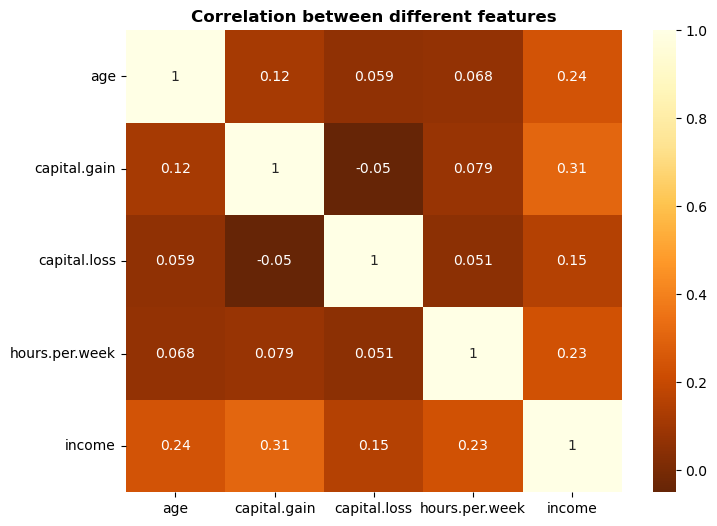

In [7]:
plot_numeric_feature_correlation(train_data)

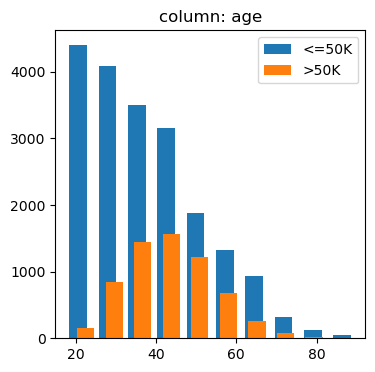

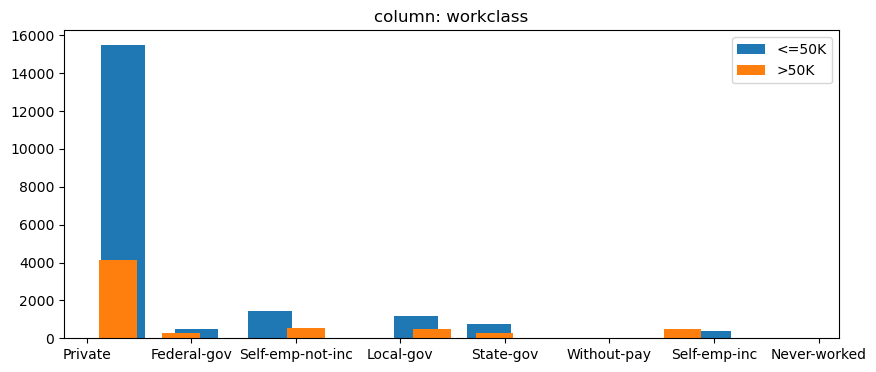

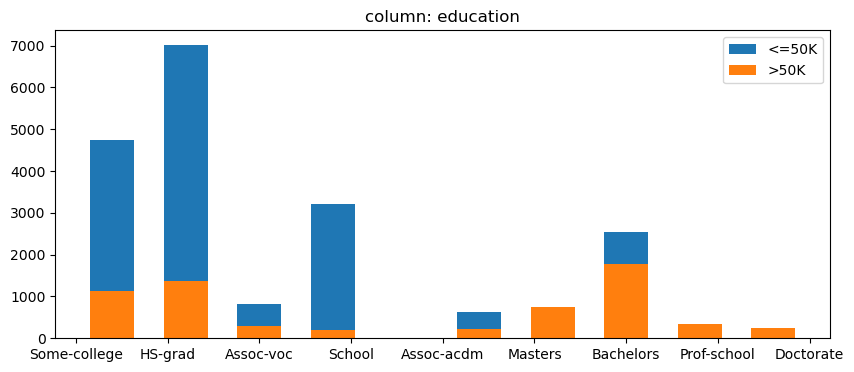

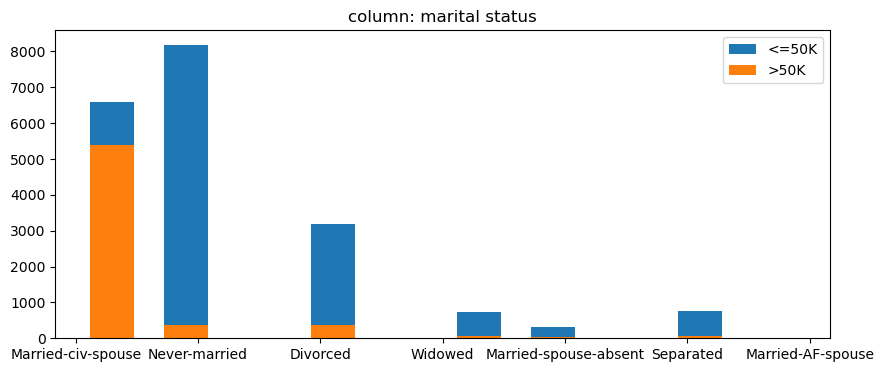

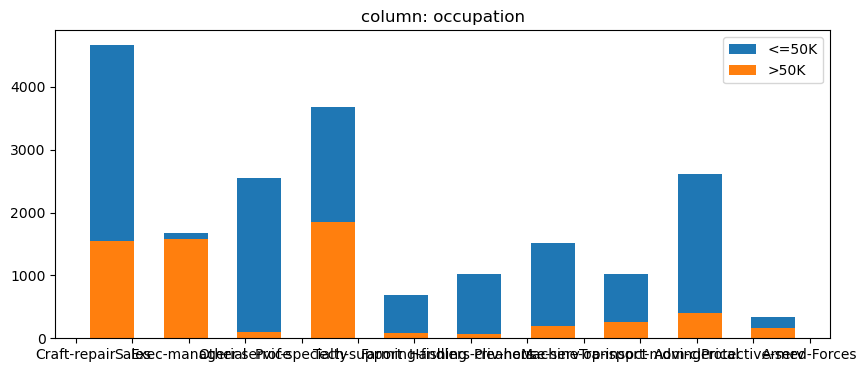

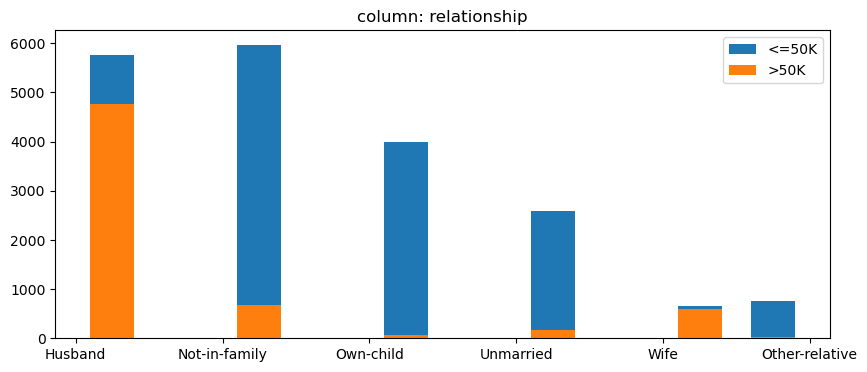

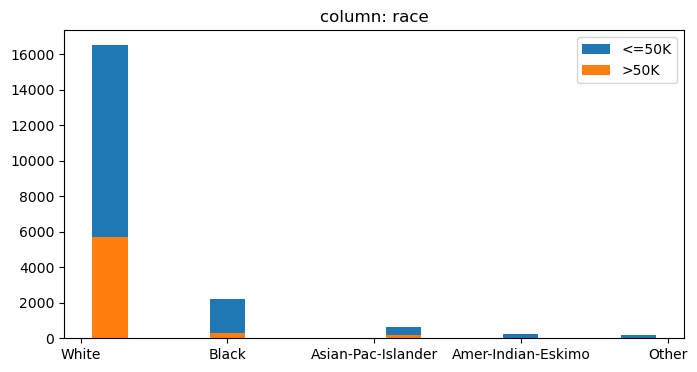

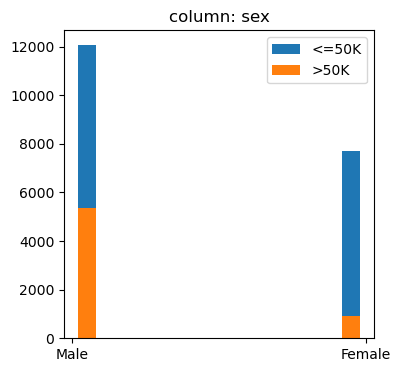

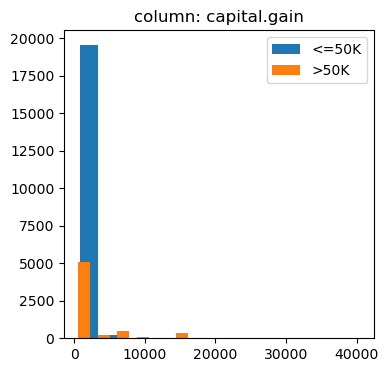

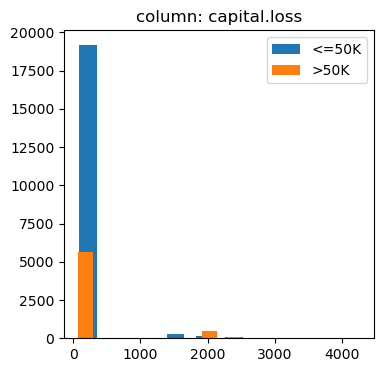

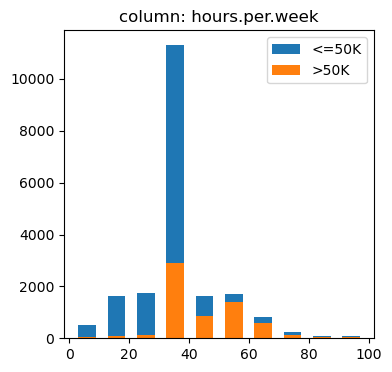

In [13]:
plot_histogram(train_data)

In [14]:
# train_data